# CS345 Final Project - Classification of Misinformation

Benjamin Ayala & Ryan Coops

In this notebook we will take a look at a couple different classifiers, their capability of disseminating real from fake news information, and how the vectorization vs. transformation of our data will change them. Starting with 3 distinct datasets, essentially 2 of them, with one of them being split into Fake & True individual sets, we will go about sanatizing the text, vectorizing/transforming, and running all the data through our classifiers.

To start our (WELFake) is a dataset of 72,134 news articles with 35,028 real and 37,106 fake news. For this, authors merged four popular news datasets (i.e. Kaggle, McIntire, Reuters, BuzzFeed Political) to prevent over-fitting of classifiers and to provide more text data for better ML training.

Published in:
IEEE Transactions on Computational Social Systems: pp. 1-13 (doi: 10.1109/TCSS.2021.3068519).

Our secondary dataset is from Kaggle, and the associated project can be found here (https://www.kaggle.com/code/therealsampat/fake-news-detection). This latter set is not nearly as rigorously defined as the WELFake dataset and so further research would include validation of all data before any form of classification. For the purposes of this class and final project, we will take it on good faith that the set is well labeled.

To begin, we will import all of the necessary libraries, our data, and go about removing redundant info from each of the sets.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string
from google.colab import drive

In [ ]:
# Uploading our data to the collab environment allows for simple imports that would work the same way were this a local python env
WELFakeDF = pd.read_csv('WELFake_Dataset.csv')
og_fake = pd.read_csv('Fake.csv')
og_true = pd.read_csv('True.csv')

# We can take a brief look of how our data is represented in each
WELFakeDF.head()
og_fake.head()
og_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


We have a large dataset of entires already labeled with 1 or 0 in the WELFake dataset. In order to merge this dataset with the following 2 labeled as true or fake, we must format both to hold the same information.

To this end, we can remove the 'index' column from the WELFake dataset, and for the true & fake datasets, we must add the label column and ensure that both the 'title' and 'text' column hold the article title and body respectively

The Fake & True dataset has an extra column that describes the 'subject' as 'news/politicsNews/other'. We can drop this column as we are under the assumption that all the entries are part of some form of news outlet or social media post in relation to politics.

In [ ]:
WELFakeDF = WELFakeDF.drop(['index'], axis=1)
og_fake = og_fake.drop(['subject', 'date'], axis=1)
og_true = og_true.drop(['subject', 'date'], axis=1)

Now we can label each section of the Fake & True datasets in accordance to their original solo dataset and then group them into a larger set for eventual combination with the WELFake dataset.

To ensure that the labels are set in the same way as WELFake,
Fake = 1 | True = 0

In [ ]:
og_fake['label'] = 1
og_true['label'] = 0
og_fake_true = pd.concat([og_fake, og_true], ignore_index=True)

Some of the text entires have 'COUNTRY NAME (Reuters) -' at the very beginning, we don't need this. Since tokenization needs to just be the content related to the article, we can safely remove this prefix from all entries that have it.

In [ ]:
og_fake_true['text'] = og_fake_true['text'].str.replace(r'^.*?\(Reuters\)\s*-\s*', '', regex=True)

Now that the initial clean and reformatting has been conducted, we can combine all of our data into a larger set. Once concatenated, we can go about sanatizing the text for tokenization.

To this end we will:
*   Lower case all text
*   Remove punctuation
*   Remove Extra Spaces
*   Remove Stop Words (the, a, is, etc)



In [ ]:
from nltk.corpus import stopwords

import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
  if isinstance(text, str):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text) # Remove anything in square brackets
    text = re.sub("\\W"," ",text) # Replace non-word chars -> emojis, special chars, etc
    text = re.sub('https?://\S+|www\.\S+', '', text) # remove urls
    text = re.sub('<.*?>+', '', text) # remove HTML tags
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) # remove punctuation
    text = re.sub('\n', '', text) # remove newline chars
    text = re.sub('\w*\d\w*', '', text) # remove words containing numbers -> gr8, covid19, etc

    # remove stop words
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    text = ' '.join(filtered_words)

    text = re.sub('\s+', ' ', text) # remove extra spaces
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
gigaset = pd.concat([WELFakeDF, og_fake_true], ignore_index=True)
gigaset['cleaned_text'] = gigaset['title'].fillna(' ') + " " + gigaset['text'].fillna(' ')
gigaset['cleaned_text'] = gigaset['cleaned_text'].apply(clean_text)
gigaset.head()

,title,text,label,cleaned_text
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threats c...
1,NaN,Did they post their votes for Hillary already?,1,post votes hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general says charl...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu uses story christian...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unvelis image terrifying new supe...


Now we can tokenize the dataset and get it ready for classification. We will initialize the Vectorizer and set the max features to 5000, with ngram being 1-2, allowing for single words and pairs of consecutive words in our features

In [ ]:
X = gigaset['cleaned_text']
y = gigaset['label']

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_vec = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

# Direct Tokenized Classifiers

Now that we have cleaned the data and tokenized it, we can go about using our classifiers to... classify. Our approach thus far has relied on bag-of-words encoding, which can sometimes lose context for longer articles. Nevertheless, it's still worthwhile to see how it performs.

## Direct SVM
First up, we're going to try SVMs. SVMs are appealing since we have a binary output and many dimensions. This may or may not work due to the large number of samples.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn import svm

In [ ]:
classTest = svm.SVC(kernel="rbf", gamma=1)

cv = StratifiedKFold(n_splits=5, random_state=0, shuffle=True)

accuracy = cross_val_score(classTest, X_train, y_train, cv=cv, scoring='accuracy')
np.mean(accuracy)

In [ ]:
# First, we need to see if accuracy good with any hyperparameters, which'll vary by kernel. This code block is the linear kernel.
param_grid = [{'C': [0.1,1, 10, 100, 1000],
              'kernel': ['linear']}
              ]

gridClass = GridSearchCV(svm.SVC(), param_grid)

gridClass.fit(X_train, y_train)

In [ ]:
# this is the bare minimum to see if I can do one (1) linear svm
minClass = svm.SVC(kernel="linear",C=10)
minClass.fit(X_train,y_train)
y_min_pred = minClass.predict(X_test)
np.mean(y_test == y_min_pred)
# even this one takes >10 minutes to run. Not promising.

Well, those took way too long to run to discern their value. So that's kind of useless. I'm kinda tempted to do PCA since it might reduce dimensionality corresponding to filler words like, "the" and "like". Maybe in a bit

## PCA into SVM
Our data takes too long to run for even a single, minimal SVM. This is a problem due to Google Collab timing out and termininating the session. It's not entirely unreasonable for a model to take a while to train, but we do have limits on how long that can take for this project. Given that we need to optimize hyperparameters and tinker with code, it's probably unreasonable for the naivest linear SVM to take thirty minutes. Our data may contain a fair amount of infrequently used words due to the nature of our inputs and also a number of constantly used words that aren't filtered out by stopwords, e.g. words like President. Both of these categories may have low variance, making them likely valid targets for removal by PCA, which will allow us to compress our 5000 dimensions to something more managable.

In [ ]:
from sklearn.decomposition import PCA
from sklearn import svm

In [ ]:
# We have to use X_vec and then split after that. Don't want our PCAs to differ between train and test splits
pca = PCA(n_components=500)
X_pca500 = pca.fit_transform(X_vec)
X_trP500, X_teP500, y_trP500, y_teP500 = train_test_split(X_pca500, y, test_size=0.2, random_state=108)

In [ ]:
# test again on a very basic SVM, just to see if we can get it to run
minClass = svm.SVC(kernel="linear",C=10)
minClass.fit(X_trP500,y_trP500)
y_min_predP500 = minClass.predict(X_teP500)
np.mean(y_teP500 == y_min_predP500)

The runtime for PCA is about 3 minutes. The runtime for the SVM is still quite long, which was killed at 30 minutes. It is doubtful that SVM is a good method for this dataset. Lets truncate the sets to see what our expected accuracy would be.

In [ ]:
minClass = svm.SVC(kernel="linear",C=10)
minClass.fit(X_trP500[:200],y_trP500[:200])
y_min_predP500 = minClass.predict(X_teP500[:100])
np.mean(y_teP500[:100] == y_min_predP500)

np.float64(0.83)

Viola! We just have too much data to really train everything or optimize our hyperparameters. That being said, 83% accuracy isn't terrible, given how simple the model was. Out of curiosity, let's repeat this on the non-PCA sample, to see if that helped at all.

In [ ]:
minClass = svm.SVC(kernel="linear",C=10)
minClass.fit(X_train[:200],y_train[:200])
y_min_pred = minClass.predict(X_test[:100])
np.mean(y_test[:100] == y_min_pred)

np.float64(0.85)

These are pretty similar in terms of run-time. Accuracy is slightly better without PCA. Let's do a bit of hyperparameter optimization to see what our outcomes might've been if we could train on everything.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = [{'C': [0.1,1, 10, 100, 1000],
              'kernel': ['linear','rbf']}
              ]
gridClass = GridSearchCV(svm.SVC(), param_grid)

gridClass.fit(X_train[:1000], y_train[:1000])

GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [0.1, 1, 10, 100, 1000],
                          'kernel': ['linear', 'rbf']}])

In [ ]:
gridClass.best_estimator_

SVC(C=1, kernel='linear')

So our previous hyperparameters of C=10 and a linear kernel weren't too far off. Let's see how it works on a larger training set. Gradually incrementing this up from 2000 training and 1000 test sets. We've settled on 20000 training point and 8000 test points, since this takes seven minutes to run, and that's the extent of what we feel to be reasonable for this project.

In [ ]:
bestSVM = svm.SVC(kernel="linear",C=10)
truncNum = 20000
X_train_trunc = X_train[:truncNum]
y_train_trunc = y_train[:truncNum]
X_test_trunc = X_test[:int(truncNum/2.5)]
y_test_trunc = y_test[:int(truncNum/2.5)]
bestSVM.fit(X_train_trunc,y_train_trunc)
y_svm_pred = minClass.predict(X_test_trunc)
np.mean(y_test_trunc == y_svm_pred)

It'd also be nice to have a confusion matrix to show the false negative/false positive rate.

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

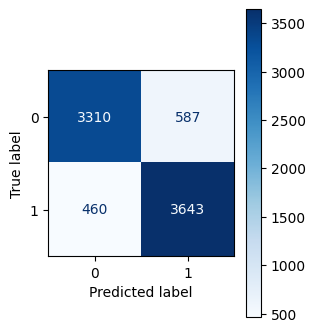

In [ ]:
svmConfMatrix = confusion_matrix(y_test_trunc, y_svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=svmConfMatrix)
fig, ax = plt.subplots(figsize=(3,4))
disp.plot(ax=ax, include_values=True, cmap=plt.cm.Blues);


This seems really quite balanced. There were initial worries that we'd get a model that just would call everything misinformation, but it turns out our data set is more balanced than that, as shown below. This classifier seems reasonably promising in that it lacks obvious systemic skew.

In [ ]:
np.mean(y)

np.float64(0.5176960147651924)

## Direct kNN
Nearest neighbors classification holds more hope, since we are feeding the model the results of effectively word choices. This will basically sort articles into clusters by editor/writer, and within those clusters journalistic standards are likely to be fairly similar. Statistically, this is a dubious way to answer the question, since our proxy variable of word choice is confounded by author, but for training an automated model it should be epistemologically fine. Quibbling aside, this should run better than SVM since kNN is O(nd) while SVM is O(n^3). The dimension count is much smaller than the sample size, so in theory, this should work. As with our SVM tests, a practicality test is run first.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
kNN_Class = KNeighborsClassifier(4)
kNN_Class.fit(X_train,y_train)
y_knn_pred1 = kNN_Class.predict(X_test)
np.mean(y_test == y_knn_pred1)


np.float64(0.7948476951339343)

This clearly has a workable run-time, so we can move on to optimization. Gridsearch was taking forever to run and wasn't giving real outputs, so instead we can do it manually.

In [ ]:
num_neighbors = [1,2,3,5,10,15]
val_accuracy = []
for k in num_neighbors :
    classifier = KNeighborsClassifier(k, p=2, weights='uniform')
    X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=k)
    classifier.fit(X_train2, y_train2)
    y_pred = classifier.predict(X_val)
    val_accuracy.append(np.sum(y_pred == y_val)/len(y_val))



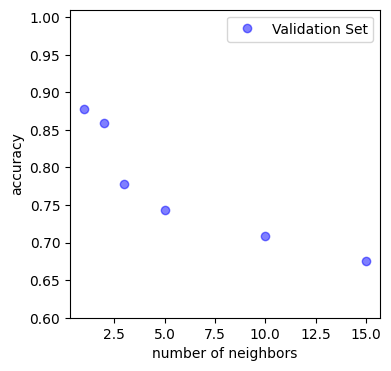

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(num_neighbors, val_accuracy, 'ob', alpha=0.5, label = 'Validation Set')
plt.ylim((0.6,1.01))
plt.xlabel('number of neighbors')
plt.ylabel('accuracy');
plt.legend();

Well, it looks like our data set's optimal number of nearest neighbors is small, which is convenient, albeit not entirely expected. Our data source doesn't contain information about author or organization, which makes it hard to discern if there's a writing style contribution to linguistic similarity.

In [ ]:
kNN_Class = KNeighborsClassifier(1)
kNN_Class.fit(X_train,y_train)
y_knn_pred2 = kNN_Class.predict(X_test)
np.mean(y_test == y_knn_pred2)

np.float64(0.9092579142991413)

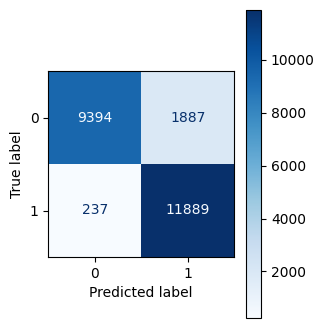

In [ ]:
kNNConfMatrix = confusion_matrix(y_test, y_knn_pred2)

disp = ConfusionMatrixDisplay(confusion_matrix=kNNConfMatrix)
fig, ax = plt.subplots(figsize=(3,4))
disp.plot(ax=ax, include_values=True, cmap=plt.cm.Blues);

So our accuracy is a solid 91%, though it seems like our false positive rate is a bit high. We've correctly identified almost all (98%) misinformation. It's gonna be hard for the transformer to beat this, but we'll see.

# Transforming Text Data with Transformer
As mentioned previously, our encoding isn't exactly ideal due to retention issues and poor handling of contextual meaning. The current standard for this problem in NLP is transformers, which should provide a rich features matrix which might be linearly separable. We're going to use a pre-trained transformer called distilbert-base-uncased, which is supposed to be a relatively light model with whole sentence contextualization.

In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch

In [ ]:
transSet = pd.concat([WELFakeDF, og_fake_true], ignore_index=True)
transSet['cleaned_text'] = transSet['title'].fillna(' ') + " " + transSet['text'].fillna(' ')
transSet = transSet.drop(['text','title'],axis=1)
transSet.head()

,label,cleaned_text
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,1,Did they post their votes for Hillary already?
2,1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,1,SATAN 2: Russia unvelis an image of its terrif...


Now we choose our model. What's selected so far is distilbert-base-uncased, which was developed by Google. It's been selected for ease of support and accuracy, at expense of speed.

In [ ]:
model_name = "distilbert-base-uncased"
transTokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Now we autotokenize the transformer gigaset using our model. This needs to be processed in small chunks since Google Colab will run out of ram and kill itself, losing all our progress. Beyond this constraint, the transformer also takes a great deal of time, averaging about 7 minutes for 351 samples. We'll need at least 2800 samples to train anything, so 56 minutes. Yikes.

Processing in small chunks, due to GoogleCollab overshooting its ram.

In [ ]:
def transTokens(sample2, tokenizer2, model2):
  inputs = tokenizer2(sample2,
                          return_tensors="pt",
                          truncation=True,
                          padding=True,
                          max_length=512)
  #run through the model
  with torch.no_grad():
      outputs = model2(**inputs)
     # You can use the CLS token representation (pooled output)
  cls_embedding = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]
  return cls_embedding.squeeze().numpy()


In [ ]:
transTokens(transSet['cleaned_text'][:(351-1)].to_list(),transTokenizer,model).shape

(350, 768)

In [ ]:
embeddingAutoToken =transTokens(transSet['cleaned_text'][:(351-1)].to_list(),
                                transTokenizer,
                                model)
howmuch = 8
for i in np.arange(1,howmuch+1):
  embeddingAutoToken= np.vstack((embeddingAutoToken,
                                 transTokens(transSet['cleaned_text'][350*i:((i+1)*351-i)].to_list(),
              transTokenizer,
              model)))

Well, that took quite a while, but as we can see, we now have a reasonably sized sample upon which to train models.

In [ ]:
embeddingAutoToken.shape

(3158, 768)

Let's split this into training and test sets now.

In [ ]:
tr_X_train, tr_X_test, tr_y_train, tr_y_test = train_test_split(embeddingAutoToken,
                                                    transSet['label'][:embeddingAutoToken.shape[0]],
                                                    test_size=0.2,
                                                    random_state=46)

## Transformed kNN
Our most successful classifier to date has been a nearest neighbors classifier with one neighbor considered. Hypothetically, we should be able to outpace the 91% accuracy, but due to containing less data in our training set, that might be difficult. Let's run the same hyperparameter optimization first.

In [ ]:
num_neighbors = [1,2,3,5,10,15]
valTr_accuracy = []
for k in num_neighbors :
    classifier = KNeighborsClassifier(k, p=2, weights='uniform')
    X_train3, X_val, y_train3, y_val = train_test_split(tr_X_train,
                                                        tr_y_train,
                                                        test_size=0.2,
                                                        random_state=k)
    classifier.fit(X_train3, y_train3)
    y_pred = classifier.predict(X_val)
    valTr_accuracy.append(np.sum(y_pred == y_val)/len(y_val))

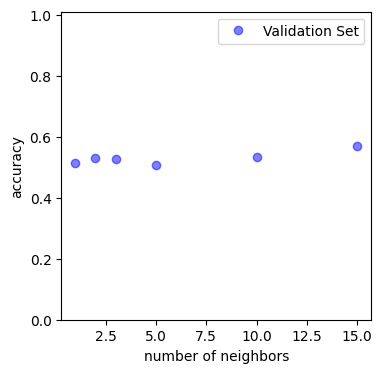

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(num_neighbors, valTr_accuracy, 'ob', alpha=0.5, label = 'Validation Set')
plt.ylim((0.0,1.01))
plt.xlabel('number of neighbors')
plt.ylabel('accuracy');
plt.legend();

Seems like our ideal number of nearest neighbors is 15, though all these numbers are barely better than randomly guessing\.

In [ ]:
kNN_Class = KNeighborsClassifier(15)
kNN_Class.fit(tr_X_train,tr_y_train)
tr_y_knn_pred = kNN_Class.predict(tr_X_test)
np.mean(tr_y_test == tr_y_knn_pred)

np.float64(0.5632911392405063)

This gives us an accuracy of 56.3%, which is much worse than our non-transformed data. This isn't entirely unpredictable, and may be because our sample size is a tiny fraction of what we did the first time. We'll see if the SVM suffered too to see if the issue is the sample size or that this encoding technique didn't work.

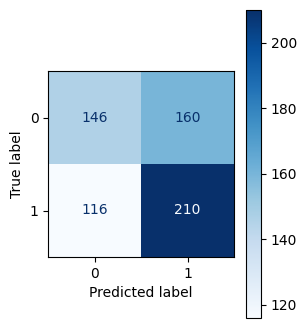

In [ ]:
tr_kNNConfMatrix = confusion_matrix(tr_y_test, tr_y_knn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=tr_kNNConfMatrix)
fig, ax = plt.subplots(figsize=(3,4))
disp.plot(ax=ax, include_values=True, cmap=plt.cm.Blues);

This confusion matrix suggests that our kNN erred on the side of calling most things misinformation, which isn't good, though with the overall accuracy as low as it is, not much can be expected

## Transformed SVM
We can probably get away with doing this here, since we have a much smaller data set due to compute restrictions on the transformation. Maybe it'll outperform kNN now. Maybe not, but accuracy should still be higher than before if the transformer worked. Same optimizations have been tried.

In [ ]:
param_grid = [{'C': [0.1,1, 10, 100, 1000],
              'kernel': ['linear','rbf']}
              ]
tr_gridClass = GridSearchCV(svm.SVC(), param_grid)

tr_gridClass.fit(tr_X_train[:1000], tr_y_train[:1000])

GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [0.1, 1, 10, 100, 1000],
                          'kernel': ['linear', 'rbf']}])

In [ ]:
tr_gridClass.best_estimator_

SVC(C=1)

Looks like our margin hyperparameter is 1, using the linear kernel. Once again, gamma is unoptimized, which might undercut the performance of the Gaussian kernel, but it's outside of the computational limits of Google Colab, so we make due.

Moving on, we train on our whole transformed set and see how well our SVM works now.

In [ ]:
tr_bestSVM = svm.SVC(kernel="linear",C=1)
tr_bestSVM.fit(tr_X_train,tr_y_train)
tr_y_svm_pred = tr_bestSVM.predict(tr_X_test)
np.mean(tr_y_test == tr_y_svm_pred)

np.float64(0.5759493670886076)

Looks like our accuracy is a paltry 57.6%. This is probably not a function of the sample size, as we got much better accuracies with comparable data in the manually tokenized data. It seems like in attempting to correct for synonyms and add greater context, we may have paved over the word choices that indicated lying.

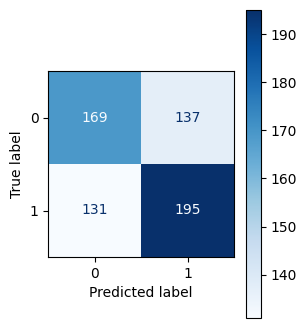

In [ ]:
tr_svmConfMatrix = confusion_matrix(tr_y_test, tr_y_svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=tr_svmConfMatrix)
fig, ax = plt.subplots(figsize=(3,4))
disp.plot(ax=ax, include_values=True, cmap=plt.cm.Blues);

And finally, looks like false negatives/false positives are roughly equal, but this just didn't do a very good job in any regard, so expected.

In [ ]:
#this is just to recall important code. We can delete it later.
X_vec.shape

(117032, 5000)

# Results, Conclusion, and Discussion

Our purpose of this project was to explore the performance of traditional classifiers accross two text representation strategies: **TF-IDF vectorization** and **transformation embedding via Distilbert**. Our preprocessing, reduced the raw text into sanitized, lower-dimensional forms, first through **TfidVectorizer** (*5k features w/ unigrams and bigrams*) and later via pre-trained contextual embeddings in our transformation process.

Using TF-IDF, the k-Nearest Neighbor classifier achieve a peak accuracy of **91%** at *k=1*, though it demonstrated a tendency to **overclassify** samples as misinformation. SVM, with a soft margin of *C=1*, reached **86%** accuracy, though on a reduced sample of 20k train / 8k test. This, as described, was more so due to our runtime constraints on Google Colab.

As for our Distilbert transformation encoding, our results of **56%** on kNN and **58%** for SVM definitively show weaker performance. While we initially hypothesized that contextual embeddings might improve performance, the outcomes imply that there is a larger issue.** Although the transformation might have helped keep context, it may have paved over the word choices that indicated lying.** A shuffle before transformation may change this outcome, though given the time constraint of the overall project we must accept these results.

This notebook provided us with valuable insight and allowed for us to explore the *effects of vectorization vs. transformation* on our data. It showed us that bag-of-words models, combined with traditional classifiers still offers valuable insight into this domain of data. As well, it helped us understand some of the more subtle nuances that comes with added contextual encodings like DisitlBert.

Moving forwared, future work might focus on transformer models more tuned to domain-specific data (*real/fake news, hyperbolic tags, etc.*). As well, a **mixture** of TF-IDF and contextual transformations might help smooth over the loss in accuracy described in our transformer models.

What we can conclude from this project is that although modern NLP tools can offer an increase in contextual embedding, classic techniques can still be effective, provided the proper preprocessing and model tuning take place.

-------------------------------------------------

# Team Member Contributions:
This project was the work of **Benjamin Ayala and Ryan Coops.**

Ben handled sourcing the data, preprocessing (sanitization, removel of stop words, etc) and combining of all the data, as well as vectorization via TF-IDF. The intro and conclusion writups and a text formatting pass through the entire notebook were also handled by Ben.

Ryan handled the majority of all data analysis, training classifiers, finding hyperparameters, and follow up analysis on each of the models. As well, Ryan handled the usage of transformation via DistilBERT and writeups for comparisions oof vectorization and transformation on classification of the data.